# 개요

- 제곱 손실은 잔차에 **제곱으로** 가중하므로 outlier 하나가 전체 해를 끌고 간다.
- $\rho$ 를 바꿔 큰 잔차의 영향을 줄이고, 그것을 **가중치 재계산만으로** 기존 GN/LM에 끼워 넣는다.

# 1. Robust Estimation

- `최소제곱` $\rho(s) = s$
	- 관측이 전부 같은 분포에서 왔다는 가정. 오매칭 하나에 무너진다
- `M-estimator` $\rho$ 를 포화시킨다
	- 큰 잔차의 영향을 제한한다. 코드 변경은 가중치 한 줄

---
## 1.1. 목적함수

$$
\boxed{
F(x) = \frac{1}{2}\sum_{i} \rho\!\left(r_{i}(x)^{2}\right)
}
$$

- $\rho$: robust loss. $\rho(s) = s$ 면 보통 최소제곱으로 돌아온다

---
## 1.2. IRLS — 가중치로 환원된다

연쇄법칙으로 gradient를 쓰면 $\rho$ 의 도함수가 각 잔차에 곱해진 형태가 된다.

$$ g = \nabla F = \sum_{i} \rho'\!\left(r_{i}^{2}\right) r_{i} J_{i}^{T} = J^{T}Wr $$

같은 가중치를 $H$ 에도 그대로 쓰면 **가중 정규방정식**이 된다.

$$
\boxed{
J^{T}WJ\,\delta = -J^{T}Wr, \qquad W = \operatorname{diag}\!\left(\rho'(r_{i}^{2})\right)
}
$$

즉,

> 잔차가 큰 관측일수록 이번 반복에서 발언권을 줄인다

매 반복 $r$ 로 $W$ 를 다시 계산하므로 `Iteratively Reweighted Least Squares`다. 기존 GN/LM
코드에 $W$ 한 줄만 꽂으면 되는 것이 이 방법의 강점이다.

---
## 1.3. 어떤 $\rho$ 를 쓰는가

임계 $k$ 를 넘는 잔차를 어떻게 다룰지가 전부다. Huber의 가중치는 다음과 같다.

$$
\boxed{
w_{\text{Huber}}(r) = \min\!\left(1,\ \frac{k}{|r|}\right)
}
$$

$|r| \le k$ 면 1(제곱손실 그대로), 넘으면 $k/|r|$ 로 줄어 **$L_1$ 처럼** 선형이 된다.

| $\rho$ | 가중치 $w(r)$ | 성질 |
|---|---|---|
| $L_2$ | $1$ | outlier에 무방비 |
| Huber | $\min(1, k/\lvert r\rvert)$ | 볼록. 국소최소가 하나 |
| Cauchy | $1/(1 + (r/k)^{2})$ | 비볼록. 영향이 계속 줄어든다 |
| Tukey | $(1-(r/k)^{2})^{2}$ if $\lvert r\rvert<k$ else $0$ | 임계 밖을 완전히 버린다 |

---
## 1.4. 전체 파이프라인

$$ \boxed{ r \rightarrow W = \operatorname{diag}(w(r_i)) \rightarrow J^{T}WJ\,\delta = -J^{T}Wr \rightarrow x + \delta \rightarrow \text{반복} } $$

```txt
   x_k
    |
    r  ---> w(r) ---> W          가중치만 매 반복 다시 계산
    |                 |
    J ----------------+
                      |
          (J^T W J + lam D) d = -J^T W r      <- LM 은 그대로 둔다
                      |
                  x_{k+1}
```

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# numpy 2.x + Apple Accelerate 조합에서 matmul 이 부동소수점 상태 플래그를 잘못 남긴다.
# 결과값은 전부 정상이라(직접 대조해 확인했다) 이 조합에서만 나오는 잡음만 끈다.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)


def pick_korean_font():
    """한글과 수학 마이너스(U+2212)를 **둘 다** 가진 폰트를 우선 고른다.

    로그 축 눈금은 $\mathdefault{10^{-13}}$ 로 그려지는데, mathtext 는 여기서 font.family 를
    쓴다. AppleGothic 계열에는 U+2212 가 없어서 지수의 마이너스가 네모로 깨진다 —
    한글은 멀쩡해서 알아채기 어렵다.
    """
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ("Arial Unicode MS", "Noto Sans CJK KR", "NanumGothic",
                  "Malgun Gothic", "Apple SD Gothic Neo", "AppleGothic")
    fallback = None
    for name in candidates:
        if name not in available:
            continue
        fallback = fallback or name
        try:
            path = font_manager.findfont(font_manager.FontProperties(family=name),
                                         fallback_to_default=False)
            if font_manager.get_font(path).get_char_index(0x2212):
                return name, True
        except Exception:
            continue
    return fallback, False


_font, _has_minus = pick_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
    plt.rcParams["axes.unicode_minus"] = _has_minus   # 없으면 ASCII 하이픈으로 대체
    plt.rcParams["mathtext.fontset"] = "dejavusans"
print(f"font: {_font}  (U+2212 보유: {_has_minus})")

font: Arial Unicode MS  (U+2212 보유: True)


## 0. 샘플 데이터 생성하기

- `03` 과 같은 곡선에 **10% 의 outlier** 를 섞는다. 노이즈가 아니라 다른 분포에서 온 값이다.
- 어느 관측이 outlier인지 마스크로 알고 있으므로, 알고리즘이 그걸 찾아냈는지 채점할 수 있다.

In [2]:
import importlib
import problems
importlib.reload(problems)                 # 커널을 재시작하지 않아도 최신 버전을 반영
from problems import *

t, y_clean, theta_true = make_curve_data(theta_true=(2.5, -0.7, 0.5), n=60, noise=0.03, seed=0)
y, outlier_mask = add_outliers(y_clean, fraction=0.1, magnitude=3.0, seed=1)

theta_init = np.array([1.0, -0.5, 0.0])

print("관측 %d 개 중 outlier %d 개 (%.0f%%)"
      % (len(y), outlier_mask.sum(), 100 * outlier_mask.mean()))
print("theta_true :", theta_true)

관측 60 개 중 outlier 6 개 (10%)
theta_true : [ 2.5 -0.7  0.5]


# 1. 데이터 시각화

outlier가 어디에 찍혔는지 눈으로 확인한다.

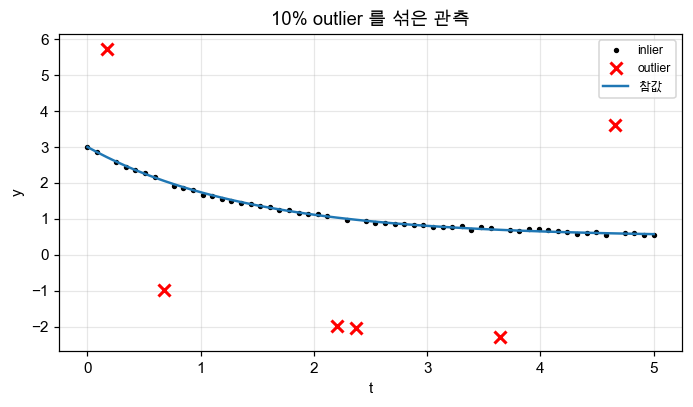

In [3]:
def show_fit(t, y, curves, labels, title="곡선 맞춤", mask=None):
    """03 과 같은 함수. outlier 를 따로 표시할 수 있게 mask 를 받는다."""
    plt.figure(figsize=(6.4, 3.8))
    if mask is None:
        plt.plot(t, y, "k.", ms=5, label="관측")
    else:
        plt.plot(t[~mask], y[~mask], "k.", ms=5, label="inlier")
        plt.plot(t[mask], y[mask], "rx", ms=8, mew=2, label="outlier")
    for theta, label in zip(curves, labels):
        plt.plot(t, curve_model(theta, t), lw=1.6, label=label)
    plt.xlabel("t"); plt.ylabel("y"); plt.title(title)
    plt.grid(True, alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()


show_fit(t, y, [theta_true], ["참값"], title="10% outlier 를 섞은 관측", mask=outlier_mask)

# 2. Robust Loss와 IRLS

In [4]:
# 1. 가중치 함수 - w(r) = rho'(r^2)
def weights(kind, r, k=0.5):
    """잔차 r (N,) -> 가중치 (N,). k 는 inlier 로 볼 잔차의 임계값이다.

    k 를 노이즈 표준편차의 1~2 배로 잡는 것이 관례다. 여기서는 noise=0.03 이지만
    초기 반복의 잔차가 훨씬 크므로 조금 넉넉하게 준다.
    """
    a = np.abs(r)
    if kind == "L2":
        return np.ones_like(r)
    if kind == "Huber":
        return np.minimum(1.0, k / np.maximum(a, 1e-12))
    if kind == "Cauchy":
        return 1.0 / (1.0 + (r / k) ** 2)
    if kind == "Tukey":
        return np.where(a < k, (1.0 - (r / k) ** 2) ** 2, 0.0)
    raise ValueError(kind)

In [5]:
# 2. 가중 정규방정식 - J^T W J d = -J^T W r   (LM damping 은 그대로 둔다)
def irls_step(theta, t, y, lam, kind, k=0.5, max_tries=60):
    """03 의 lm_step 에 W 만 끼운 것이다. 나머지 구조는 손대지 않았다."""
    r = curve_residual(theta, t, y)               # (N,)
    J = curve_jacobian(theta, t)                  # (N, 3)
    w = weights(kind, r, k)                       # (N,)

    H = (J * w[:, None]).T @ J                    # J^T W J  (3, 3)
    g = J.T @ (w * r)                             # J^T W r  (3,)
    D = np.diag(np.maximum(np.diag(H), 1e-12))
    F = 0.5 * float(np.sum(w * r * r))            # 가중 비용

    for _ in range(max_tries):
        try:
            d = np.linalg.solve(H + lam * D, -g)
        except np.linalg.LinAlgError:
            lam *= 3.0
            continue
        r_new = curve_residual(theta + d, t, y)
        # 가중치는 이번 반복의 것으로 고정하고 비교한다 (IRLS 의 표준 처리)
        F_new = 0.5 * float(np.sum(w * r_new * r_new))
        predicted = 0.5 * float(d @ (lam * D @ d - g))
        gamma = (F - F_new) / predicted if predicted > 0 else -1.0
        if gamma > 0:
            return theta + d, max(lam / 3.0, 1e-12), True
        lam *= 3.0
    return theta, lam, False

## 2.1. 메인 루프

네 가지 $\rho$ 를 같은 초기값에서 돌린다.

In [6]:
losses = ("L2", "Huber", "Cauchy", "Tukey")
results = {}

for kind in losses:
    theta = theta_init.copy()
    lam = 1e-3
    err_history = []

    for it in range(80):
        # 1. 참값 대비 오차 기록 (채점용, 알고리즘은 쓰지 않는다)
        err_history.append(np.linalg.norm(theta - theta_true))
        # 2. 잔차 -> 가중치 -> 가중 정규방정식 -> 갱신
        theta, lam, accepted = irls_step(theta, t, y, lam, kind, k=0.5)
        if not accepted:
            break

    r_final = curve_residual(theta, t, y)
    results[kind] = dict(theta=theta, errs=err_history, w=weights(kind, r_final, 0.5))
    print(f"{kind:7s} |theta-theta*| = {np.linalg.norm(theta - theta_true):8.4f}   theta = {theta}")

L2      |theta-theta*| =   0.9149   theta = [ 3.1535 -1.3302  0.6127]
Huber   |theta-theta*| =   0.1713   theta = [ 2.5742 -0.8373  0.5706]
Cauchy  |theta-theta*| =   0.0437   theta = [ 2.4971 -0.7331  0.5283]
Tukey   |theta-theta*| =   0.0260   theta = [ 2.4851 -0.7124  0.5174]


# 3. 검증

참값을 알고 있고 어느 관측이 outlier인지도 알고 있다. 둘 다 채점한다.

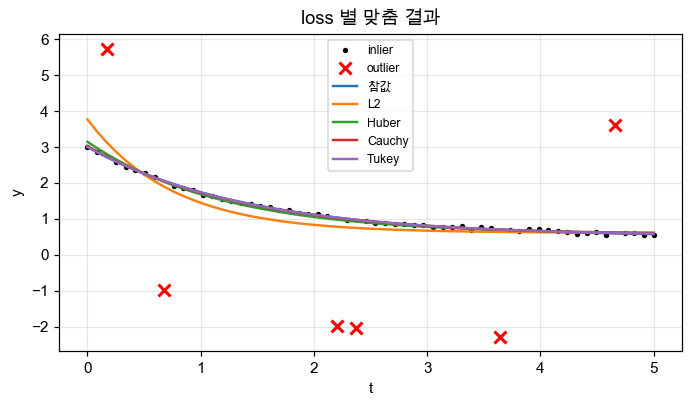

In [7]:
show_fit(t, y, [theta_true] + [results[k]["theta"] for k in losses],
         ["참값"] + list(losses), title="loss 별 맞춤 결과", mask=outlier_mask)

In [8]:
# outlier 에 실제로 낮은 가중치가 갔는가 - 이게 IRLS 가 한 일의 전부다
print(f"{'loss':8s} {'inlier 평균 w':>14s} {'outlier 평균 w':>15s} {'비율':>8s}")
for kind in losses:
    w = results[kind]["w"]
    w_in, w_out = w[~outlier_mask].mean(), w[outlier_mask].mean()
    ratio = w_out / w_in if w_in > 0 else np.nan
    print(f"{kind:8s} {w_in:14.4f} {w_out:15.4f} {ratio:8.3f}")

loss        inlier 평균 w    outlier 평균 w       비율
L2               1.0000          1.0000    1.000
Huber            1.0000          0.1684    0.168
Cauchy           0.9969          0.0270    0.027
Tukey            0.9942          0.0000    0.000


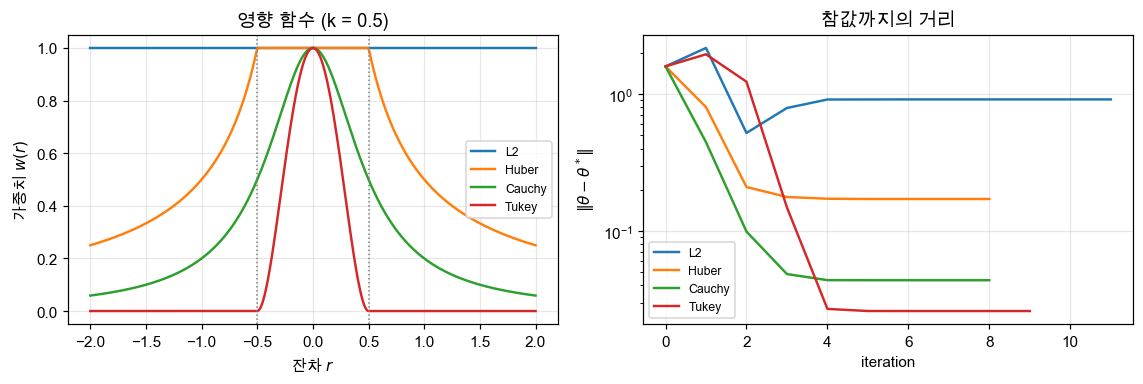

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

# 왼쪽: 가중치 함수 모양
rr = np.linspace(-2.0, 2.0, 400)
for kind in losses:
    axes[0].plot(rr, weights(kind, rr, 0.5), lw=1.6, label=kind)
axes[0].axvline(0.5, color="gray", ls=":", lw=1)
axes[0].axvline(-0.5, color="gray", ls=":", lw=1)
axes[0].set_xlabel("잔차 $r$"); axes[0].set_ylabel("가중치 $w(r)$")
axes[0].set_title("영향 함수 (k = 0.5)"); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

# 오른쪽: 참값까지의 거리
for kind in losses:
    axes[1].semilogy(np.maximum(results[kind]["errs"], 1e-16), lw=1.6, label=kind)
axes[1].set_xlabel("iteration"); axes[1].set_ylabel(r"$\|\theta - \theta^*\|$")
axes[1].set_title("참값까지의 거리"); axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 3.1. $k$ 를 잘못 잡으면

임계 $k$ 는 공짜가 아니다. 너무 크면 outlier를 inlier로 보고, 너무 작으면 정상 관측까지 버린다.

In [10]:
print(f"{'k':>6s}  " + "  ".join(f"{kind:>9s}" for kind in losses))
for k in (0.1, 0.3, 0.5, 1.0, 2.0, 5.0):
    row = []
    for kind in losses:
        theta, lam = theta_init.copy(), 1e-3
        for _ in range(80):
            theta, lam, accepted = irls_step(theta, t, y, lam, kind, k=k)
            if not accepted:
                break
        row.append(np.linalg.norm(theta - theta_true))
    print(f"{k:6.1f}  " + "  ".join(f"{e:9.4f}" for e in row))

     k         L2      Huber     Cauchy      Tukey
   0.1     0.9149     0.0487     0.0269     1.5937
   0.3     0.9149     0.1085     0.0313     1.5937
   0.5     0.9149     0.1713     0.0437     0.0260
   1.0     0.9149     0.3338     0.1094     0.0260
   2.0     0.9149     0.6746     0.3153     0.0260
   5.0     0.9149     0.9149     0.7177     0.4374


## 3.2. RANSAC과의 분업

M-estimator는 **괜찮은 초기값이 있을 때** 남은 outlier를 눌러 정밀도를 올린다. 초기값이
없으면 3.1의 표처럼 $k$ 를 아무리 맞춰도 엉뚱한 골짜기로 간다.

- `RANSAC`: 초기값을 만든다. 무작위 최소 표본으로 모델을 세우고 inlier를 센다
- `M-estimator`: 그 초기값을 다듬는다

실무에서는 RANSAC → LM + Huber 순으로 이어 붙인다.

## 3.3. 한계

- $k$ 를 고정값으로 줬다. 실무에서는 MAD(median absolute deviation)로 매 반복 추정한다.
- Tukey는 비볼록이라 초기값에 민감하다. 보통 Huber로 시작해 Tukey로 넘기는 `graduated
  non-convexity` 를 쓴다.
- outlier 비율을 10%로 고정했다. 50%를 넘으면 M-estimator만으로는 복구되지 않는다.